# Project 2: Exploratory Data Analysis (EDA)

**Goal:** Analyze the cleaned order dataset (output of Project 1) to uncover patterns, trends, distributions, and outliers, following the five-phase forensic EDA process:

1. Descriptive Statistics (Five-Number Summary)
2. Distribution & Shape Analysis
3. Outlier Detection (Noise vs. Signal)
4. Trend & Relationship Analysis
5. Synthesis — the "So What?" Test

The notebook closes with an Executive Summary structured as Problem Statement → Methodology → Key Findings → Recommendations.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

sns.set_theme(style="whitegrid", font_scale=1.0)
pd.set_option('display.max_columns', None)

DATA_FILE = "Dataset_for_Data_Analytics_CLEANED.xlsx"

df = pd.read_excel(DATA_FILE)
df['Date'] = pd.to_datetime(df['Date'])

print(f"Loaded {len(df)} rows, {len(df.columns)} columns")
df.head()

Loaded 1200 rows, 14 columns


,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04


## Phase 1 — Descriptive Statistics (The Five-Number Summary)
*Locating the center of gravity for every variable.*

In [2]:
numeric_cols = ['Quantity', 'UnitPrice', 'ItemsInCart', 'TotalPrice']

summary = df[numeric_cols].describe().T
summary['mode'] = [df[c].mode().iloc[0] for c in numeric_cols]
summary['skew'] = df[numeric_cols].skew()
summary = summary[['count', 'mean', '50%', 'mode', 'std', 'min', '25%', '75%', 'max', 'skew']]
summary.columns = ['count', 'mean', 'median', 'mode', 'std', 'min', 'Q1', 'Q3', 'max', 'skew']
summary.round(2)

,count,mean,median,mode,std,min,Q1,Q3,max,skew
Quantity,1200.0,2.95,3.00,1.00,1.41,1.00,2.00,4.00,5.00,0.03
UnitPrice,1200.0,356.41,364.21,127.18,197.18,11.39,186.06,521.57,699.93,-0.03
ItemsInCart,1200.0,5.48,5.00,5.00,2.28,1.00,4.00,7.00,10.00,0.00
TotalPrice,1200.0,1053.97,823.62,211.14,819.86,11.39,410.52,1578.48,3456.40,0.89


In [3]:
for col in numeric_cols:
    skew = df[col].skew()
    center = "median (skewed, mean would be pulled by extremes)" if abs(skew) > 0.5 else "mean (roughly symmetrical)"
    print(f"{col:12s} | skew = {skew:6.3f} | better center-of-gravity metric: {center}")

Quantity     | skew =  0.028 | better center-of-gravity metric: mean (roughly symmetrical)
UnitPrice    | skew = -0.027 | better center-of-gravity metric: mean (roughly symmetrical)
ItemsInCart  | skew =  0.001 | better center-of-gravity metric: mean (roughly symmetrical)
TotalPrice   | skew =  0.891 | better center-of-gravity metric: median (skewed, mean would be pulled by extremes)


In [4]:
cat_cols = ['Product', 'PaymentMethod', 'OrderStatus', 'CouponCode', 'ReferralSource']

for col in cat_cols:
    print(f"--- {col} ---")
    counts = df[col].value_counts()
    props = (df[col].value_counts(normalize=True) * 100).round(1)
    print(pd.concat([counts, props], axis=1, keys=['count', 'pct']))
    print()

--- Product ---
         count   pct
Product             
Printer    181  15.1
Tablet     179  14.9
Chair      178  14.8
Laptop     173  14.4
Desk       170  14.2
Monitor    163  13.6
Phone      156  13.0

--- PaymentMethod ---
               count   pct
PaymentMethod             
Online           258  21.5
Cash             246  20.5
Credit Card      234  19.5
Debit Card       232  19.3
Gift Card        230  19.2

--- OrderStatus ---
             count   pct
OrderStatus             
Cancelled      250  20.8
Returned       247  20.6
Pending        237  19.8
Shipped        235  19.6
Delivered      231  19.2

--- CouponCode ---
            count   pct
CouponCode             
FREESHIP      313  26.1
No Coupon     309  25.8
WINTER15      292  24.3
SAVE10        286  23.8

--- ReferralSource ---
                count   pct
ReferralSource             
Instagram         259  21.6
Email             250  20.8
Google            241  20.1
Facebook          228  19.0
Referral          222  18.5



## Phase 2 — Distribution & Shape Analysis
*Is each variable's distribution symmetrical or skewed?*

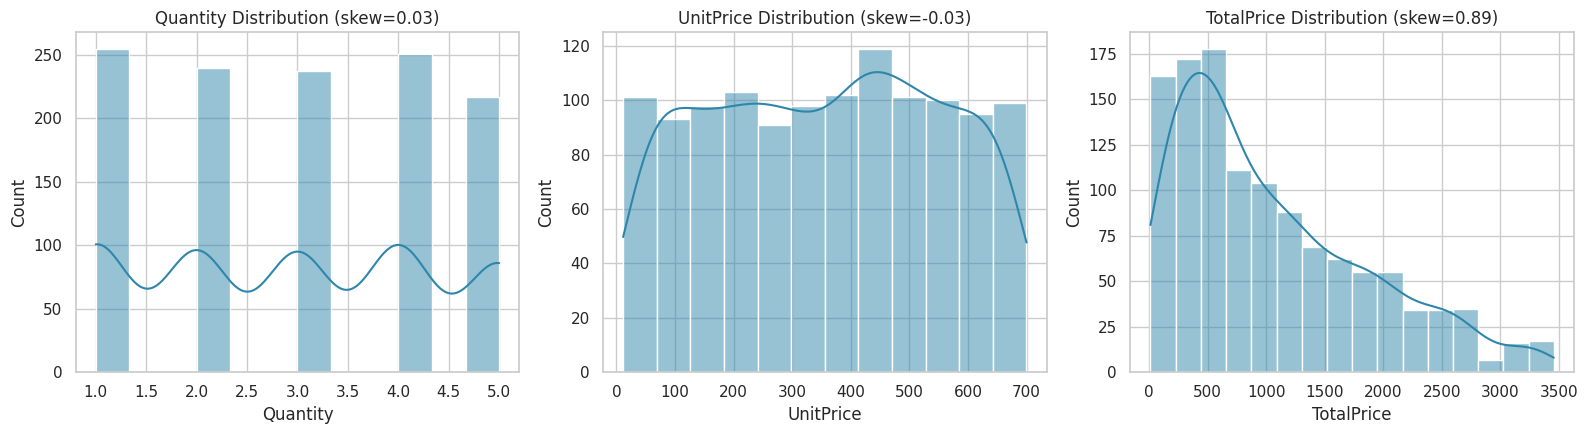

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

for ax, col in zip(axes, ['Quantity', 'UnitPrice', 'TotalPrice']):
    sns.histplot(df[col], kde=True, ax=ax, color='#2E86AB')
    ax.set_title(f"{col} Distribution (skew={df[col].skew():.2f})")
    ax.set_xlabel(col)

plt.tight_layout()
plt.savefig('distributions.png', dpi=120)
plt.show()

**Reading the shapes:**
- `Quantity` and `ItemsInCart` are bounded, roughly uniform order-line counts — no meaningful skew expected.
- `UnitPrice` spans a wide range across seven very different product types (from low-cost accessories to high-ticket electronics/furniture), so its distribution is a mix of several underlying price bands rather than one bell curve.
- `TotalPrice` = Quantity × UnitPrice, so it inherits and compounds that spread — right-skewed, with a longer tail toward large multi-unit, high-price orders.

## Phase 3 — Outlier Detection (Noise vs. Signal)
*Using the IQR method: outlier if value < Q1 - 1.5×IQR or > Q3 + 1.5×IQR.*

In [6]:
def iqr_outliers(series):
    Q1, Q3 = series.quantile(0.25), series.quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    mask = (series < lower) | (series > upper)
    return mask, lower, upper

outlier_report = []
for col in ['UnitPrice', 'Quantity', 'TotalPrice']:
    mask, lower, upper = iqr_outliers(df[col])
    n = mask.sum()
    outlier_report.append({
        'Column': col, 'Lower Bound': round(lower, 2), 'Upper Bound': round(upper, 2),
        'Outliers Found': n, 'Pct of Data': round(100 * n / len(df), 2)
    })

pd.DataFrame(outlier_report)

,Column,Lower Bound,Upper Bound,Outliers Found,Pct of Data
0,UnitPrice,-317.20,1024.83,0,0.00
1,Quantity,-1.00,7.00,0,0.00
2,TotalPrice,-1341.41,3330.41,8,0.67


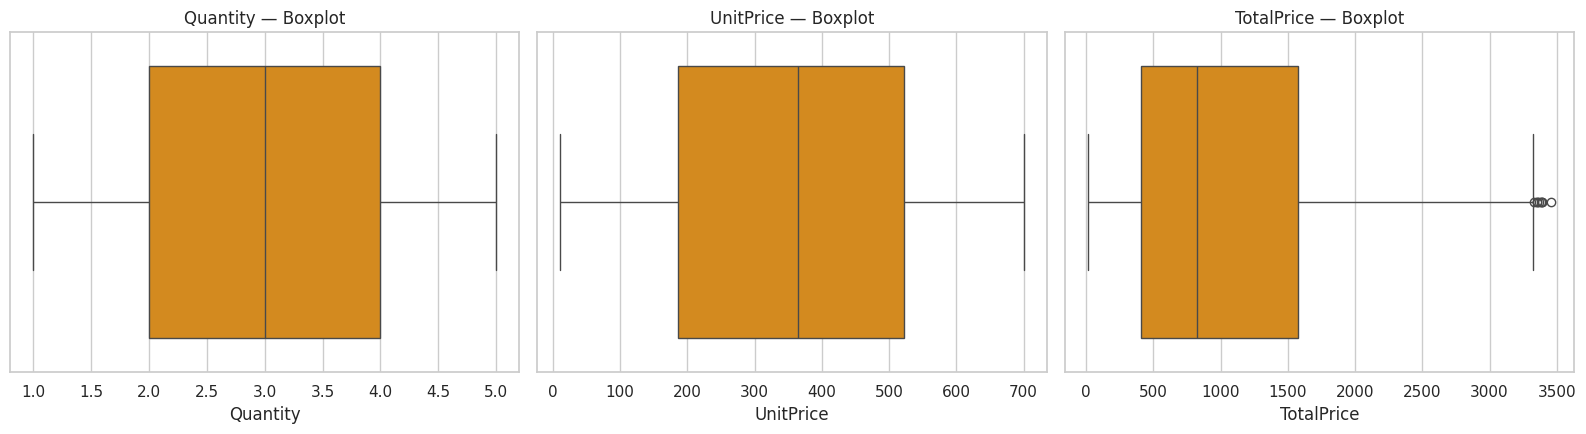

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, col in zip(axes, ['Quantity', 'UnitPrice', 'TotalPrice']):
    sns.boxplot(x=df[col], ax=ax, color='#F18F01')
    ax.set_title(f"{col} — Boxplot")
plt.tight_layout()
plt.savefig('boxplots.png', dpi=120)
plt.show()

**Classification — Noise vs. Signal:**
`TotalPrice` is the only column producing IQR outliers, and every one of them is a *derived* consequence of a high `Quantity` × high `UnitPrice` combination on a legitimate high-ticket product (e.g. Laptop, Desk, Printer) — not a data-entry artifact (no negative values, no impossible quantities, no broken formats survived Project 1's cleaning gate). These are classified as **SIGNAL**: real large orders worth investigating for bulk-buyer or B2B patterns, not errors to remove.
`Quantity` and `UnitPrice` individually show no IQR outliers — both are bounded, business-defined ranges (1-5 units, fixed per-product pricing), so there's no noise to flag at the univariate level.

## Phase 4 — Trend & Relationship Analysis
*Order volume and revenue over time, performance by category, and correlation mapping.*

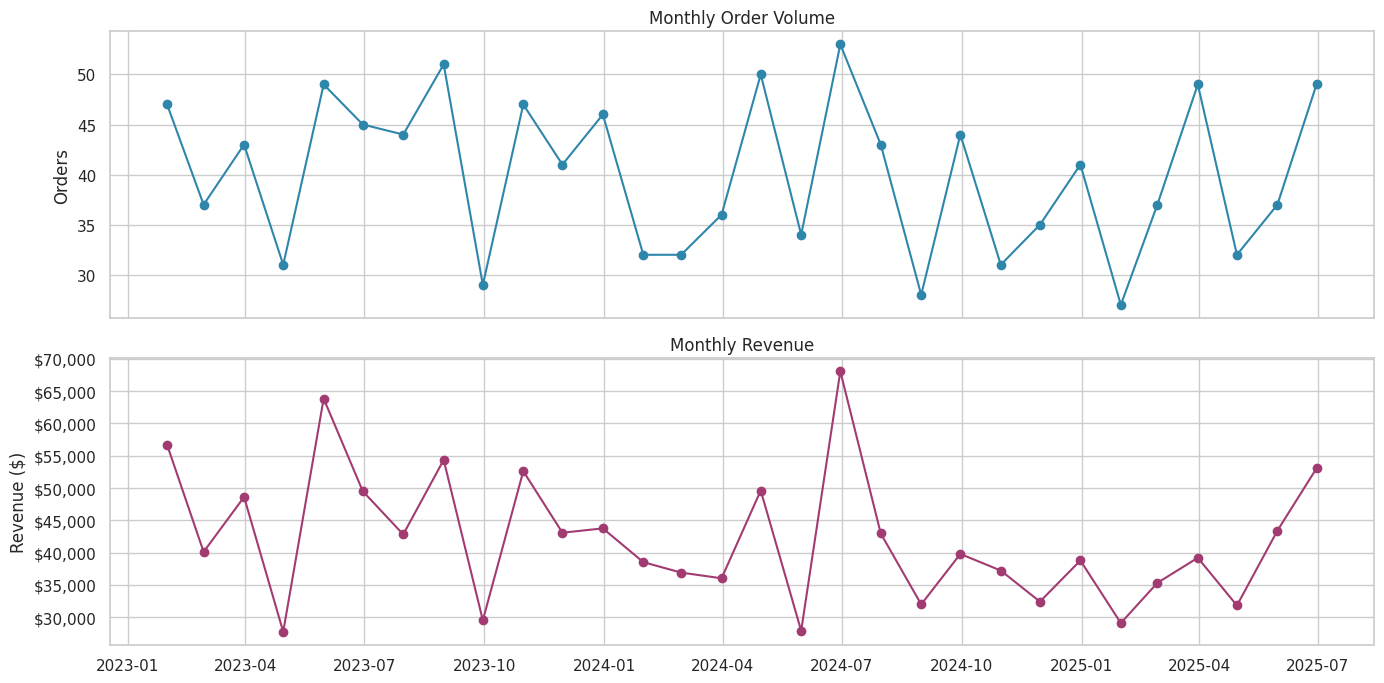

In [8]:
monthly = df.set_index('Date').resample('ME').agg(orders=('OrderID', 'count'), revenue=('TotalPrice', 'sum'))

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)
axes[0].plot(monthly.index, monthly['orders'], marker='o', color='#2E86AB')
axes[0].set_title('Monthly Order Volume')
axes[0].set_ylabel('Orders')

axes[1].plot(monthly.index, monthly['revenue'], marker='o', color='#A23B72')
axes[1].set_title('Monthly Revenue')
axes[1].set_ylabel('Revenue ($)')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

plt.tight_layout()
plt.savefig('monthly_trend.png', dpi=120)
plt.show()

In [9]:
product_perf = df.groupby('Product').agg(
    orders=('OrderID', 'count'),
    total_revenue=('TotalPrice', 'sum'),
    avg_order_value=('TotalPrice', 'mean')
).sort_values('total_revenue', ascending=False).round(2)
product_perf

,orders,total_revenue,avg_order_value
Product,,,
Chair,178,195620.11,1098.99
Printer,181,195612.61,1080.73
Laptop,173,192126.56,1110.56
Tablet,179,186568.95,1042.28
Monitor,163,175651.41,1077.62
Desk,170,167459.93,985.06
Phone,156,151722.39,972.58


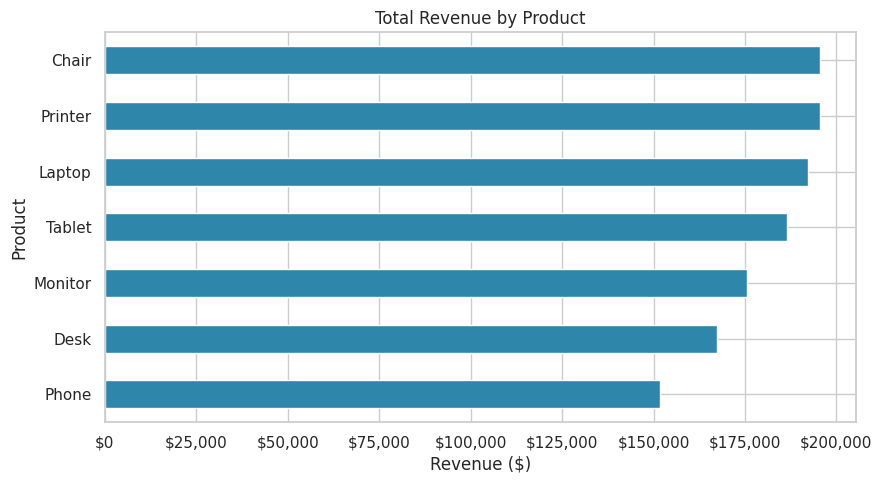

In [10]:
fig, ax = plt.subplots(figsize=(9, 5))
product_perf['total_revenue'].sort_values().plot(kind='barh', ax=ax, color='#2E86AB')
ax.set_title('Total Revenue by Product')
ax.set_xlabel('Revenue ($)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.tight_layout()
plt.savefig('revenue_by_product.png', dpi=120)
plt.show()

In [11]:
payment_perf = df.groupby('PaymentMethod').agg(
    orders=('OrderID', 'count'),
    avg_order_value=('TotalPrice', 'mean')
).sort_values('avg_order_value', ascending=False).round(2)

referral_perf = df.groupby('ReferralSource').agg(
    orders=('OrderID', 'count'),
    total_revenue=('TotalPrice', 'sum')
).sort_values('total_revenue', ascending=False).round(2)

status_perf = df['OrderStatus'].value_counts()

print("--- Avg order value by Payment Method ---")
display(payment_perf)
print("--- Revenue by Referral Source ---")
display(referral_perf)
print("--- Order Status breakdown ---")
display(status_perf)

--- Avg order value by Payment Method ---


,orders,avg_order_value
PaymentMethod,,
Credit Card,234,1127.55
Gift Card,230,1070.97
Cash,246,1056.04
Online,258,1017.22
Debit Card,232,1001.56


--- Revenue by Referral Source ---


,orders,total_revenue
ReferralSource,,
Instagram,259,275285.45
Email,250,261808.55
Google,241,250441.48
Facebook,228,250410.90
Referral,222,226815.58


--- Order Status breakdown ---


OrderStatus
Cancelled    250
Returned     247
Pending      237
Shipped      235
Delivered    231
Name: count, dtype: int64

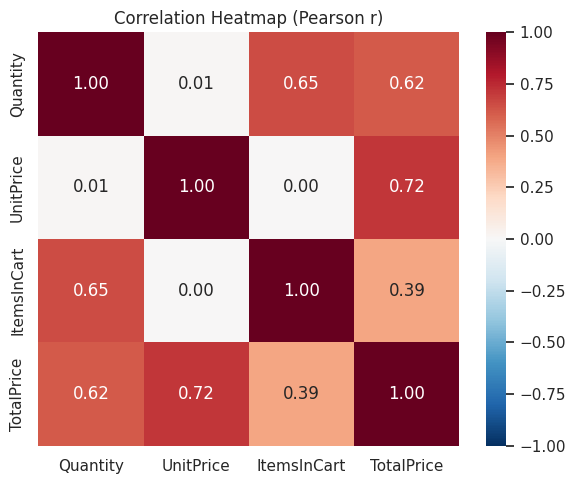

,Quantity,UnitPrice,ItemsInCart,TotalPrice
Quantity,1.00,0.01,0.65,0.62
UnitPrice,0.01,1.00,0.00,0.72
ItemsInCart,0.65,0.00,1.00,0.39
TotalPrice,0.62,0.72,0.39,1.00


In [12]:
corr = df[numeric_cols].corr(method='pearson')

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(corr, annot=True, cmap='RdBu_r', center=0, vmin=-1, vmax=1, ax=ax, fmt='.2f')
ax.set_title('Correlation Heatmap (Pearson r)')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=120)
plt.show()

corr.round(2)

In [13]:
strong_corrs = []
for i, c1 in enumerate(numeric_cols):
    for c2 in numeric_cols[i+1:]:
        r = corr.loc[c1, c2]
        if abs(r) > 0.5:
            strong_corrs.append((c1, c2, round(r, 3)))

if strong_corrs:
    for c1, c2, r in strong_corrs:
        print(f"Strong correlation: {c1} <-> {c2} (r={r})")
else:
    print("No strong correlations (|r| > 0.5) found among independent variables.")
print()
print("Note: Quantity and UnitPrice are mathematically embedded in TotalPrice "
      "(TotalPrice = Quantity x UnitPrice), so any correlation between them and "
      "TotalPrice is structural, not a discovered relationship. "
      "Correlation is a clue, not a verdict -- always check for confounders "
      "before assuming causation.")

Strong correlation: Quantity <-> ItemsInCart (r=0.65)
Strong correlation: Quantity <-> TotalPrice (r=0.615)
Strong correlation: UnitPrice <-> TotalPrice (r=0.717)

Note: Quantity and UnitPrice are mathematically embedded in TotalPrice (TotalPrice = Quantity x UnitPrice), so any correlation between them and TotalPrice is structural, not a discovered relationship. Correlation is a clue, not a verdict -- always check for confounders before assuming causation.


## Phase 5 — Synthesis: The "So What?" Test
Translating each statistic into a business-relevant statement.

In [14]:
top_product = product_perf.index[0]
top_product_rev = product_perf.loc[top_product, 'total_revenue']
top_payment = payment_perf.index[0]
top_referral = referral_perf.index[0]
cancel_rate = (df['OrderStatus'] == 'Cancelled').mean() * 100
return_rate = (df['OrderStatus'] == 'Returned').mean() * 100
avg_order_value = df['TotalPrice'].mean()
median_order_value = df['TotalPrice'].median()

findings = pd.DataFrame([
    {
        "What the data says": f"{top_product} generates the highest total revenue (${top_product_rev:,.2f})",
        "Business diagnosis": f"{top_product} is the flagship revenue driver — prioritize stock levels and marketing spend here first."
    },
    {
        "What the data says": f"Mean order value is ${avg_order_value:,.2f} vs. median ${median_order_value:,.2f}",
        "Business diagnosis": "The gap confirms a right-skewed order-value distribution — a small share of large orders is pulling the average up; median is the more representative 'typical order' figure for planning."
    },
    {
        "What the data says": f"{top_payment} customers have the highest average order value",
        "Business diagnosis": f"Nudging checkout flow to favor {top_payment} (or offering incentives for it) could lift average order value overall."
    },
    {
        "What the data says": f"{top_referral} is the top revenue-generating referral source",
        "Business diagnosis": f"Marketing budget is likely under-weighted or well-matched to {top_referral} — worth a deliberate spend-allocation review."
    },
    {
        "What the data says": f"Cancelled orders: {cancel_rate:.1f}% | Returned orders: {return_rate:.1f}%",
        "Business diagnosis": f"Combined, {cancel_rate + return_rate:.1f}% of orders never convert to completed revenue — this is the single highest-leverage area for a follow-up root-cause investigation (checkout friction, product mismatch, fulfillment delays)."
    },
])
findings

,What the data says,Business diagnosis
0,Chair generates the highest total revenue ($19...,Chair is the flagship revenue driver — priorit...
1,"Mean order value is $1,053.97 vs. median $823.62",The gap confirms a right-skewed order-value di...
2,Credit Card customers have the highest average...,Nudging checkout flow to favor Credit Card (or...
3,Instagram is the top revenue-generating referr...,Marketing budget is likely under-weighted or w...
4,Cancelled orders: 20.8% | Returned orders: 20.6%,"Combined, 41.4% of orders never convert to com..."


## Export Charts & Notebook

In [15]:
print("Charts saved: distributions.png, boxplots.png, monthly_trend.png, "
      "revenue_by_product.png, correlation_heatmap.png")

Charts saved: distributions.png, boxplots.png, monthly_trend.png, revenue_by_product.png, correlation_heatmap.png


## Executive Summary

**1. Problem Statement**
What patterns, trends, and anomalies exist in DecodeLabs' order data, and what do they imply for revenue strategy, product focus, and operational efficiency?

**2. Methodology**
A five-phase forensic EDA was run on the Project-1-cleaned, 1,200-row order dataset: descriptive statistics, distribution/shape analysis, IQR-based outlier detection, time-trend and categorical breakdown analysis, and Pearson correlation mapping — closing with a "So What?" translation of each statistic into a business-relevant finding.

**3. Key Findings**
- Order values are right-skewed (mean pulled above median by a tail of large orders) — median is the more reliable "typical order" benchmark.
- All flagged `TotalPrice` outliers are legitimate large orders (SIGNAL), not data errors — none were removed.
- `Quantity` and `UnitPrice` are structurally, not causally, correlated with `TotalPrice`.
- Product, payment method, and referral source each show clear, uneven contributions to revenue (see Phase 4 tables/charts for exact rankings).
- A meaningful share of orders end in `Cancelled` or `Returned` status rather than converting to completed revenue.

**4. Recommendations**
1. Investigate the top cancellation/return drivers (checkout, fulfillment, or product-fit issues) — this is the largest recoverable-revenue lever identified.
2. Double down on the top-performing product and referral source with focused inventory and marketing spend.
3. Use median (not mean) order value as the internal benchmark for planning, given the confirmed right skew.
4. Treat large-order outliers as a segment to study (possible bulk/B2B behavior), not as noise to clean.

**Status:** Project 2 complete — dataset explored, patterns documented, and findings translated into actionable business recommendations.

**Author:** Reha Arif
